# Deliverable 3: Linear Classification Model

## Section 0: Setup

- Spark session init
- Load the 3 .dat files
- Join into one DataFrame
- Cleaning steps (keep the filters even though data was clean — defensive code)
- Feature engineering (all your derived columns)
- Train/test split (seed=42)

In [1]:
# Verify Java installation
import os
print("JAVA_HOME is:", os.environ.get("JAVA_HOME"))
!java -version

JAVA_HOME is: /Library/Java/JavaVirtualMachines/temurin-17.jdk/Contents/Home
openjdk version "17.0.17" 2025-10-21
OpenJDK Runtime Environment Temurin-17.0.17+10 (build 17.0.17+10)
OpenJDK 64-Bit Server VM Temurin-17.0.17+10 (build 17.0.17+10, mixed mode, sharing)


In [2]:
import os
import sys

from pyspark.sql.functions import broadcast, explode, split, col, avg, round, desc, when, count, size, regexp_extract, length
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

In [3]:
import os
os.environ["JAVA_HOME"] = "/Library/Java/JavaVirtualMachines/temurin-17.jdk/Contents/Home"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = SparkSession.builder \
    .appName("Team Vortex MovieLens") \
    .master("local[*]") \
    .getOrCreate()

sc = spark.sparkContext
sc.setLogLevel("ERROR")  # Suppress warnings for cleaner output

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/21 16:33:43 WARN Utils: Your hostname, MacBook-Pro-4.local, resolves to a loopback address: 127.0.0.1; using 192.168.5.102 instead (on interface en0)
26/04/21 16:33:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/21 16:33:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
schema_users = StructType([
    StructField("UserID", IntegerType(), True),
    StructField("Gender", StringType(), True),
    StructField("Age", IntegerType(), True),
    StructField("Occupation",IntegerType(), True),
    StructField("Zip-code", StringType(), True)
])

df_users = spark.read \
    .option("header", "false") \
    .option("quote", '"') \
    .option("escape", '"') \
    .option("multiLine", "true") \
    .option("sep", "::") \
    .schema(schema_users) \
    .csv("./ml-1m/users.dat")

df_users.show(5)

schema_ratings  = StructType([
    StructField("UserID", IntegerType(), True),
    StructField("MovieID", IntegerType(), True),
    StructField("Rating", IntegerType(), True),
    StructField("Timestamp",IntegerType(), True)
])

df_ratings = spark.read \
    .option("header", "false") \
    .option("quote", '"') \
    .option("escape", '"') \
    .option("multiLine", "true") \
    .option("sep", "::") \
    .schema(schema_ratings) \
    .csv("./data/ratings_train.dat")

df_ratings.show(5)

schema_movies  = StructType([
    StructField("MovieID", IntegerType(), True),
    StructField("Title", StringType(), True),
    StructField("Genres",StringType(), True)
])

df_movies = spark.read \
    .option("header", "false") \
    .option("quote", '"') \
    .option("escape", '"') \
    .option("multiLine", "true") \
    .option("sep", "::") \
    .schema(schema_movies) \
    .csv("./ml-1m/movies.dat")

df_movies.show(5)


+------+------+---+----------+--------+
|UserID|Gender|Age|Occupation|Zip-code|
+------+------+---+----------+--------+
|     1|     F|  1|        10|   48067|
|     2|     M| 56|        16|   70072|
|     3|     M| 25|        15|   55117|
|     4|     M| 45|         7|   02460|
|     5|     M| 25|        20|   55455|
+------+------+---+----------+--------+
only showing top 5 rows
+------+-------+------+---------+
|UserID|MovieID|Rating|Timestamp|
+------+-------+------+---------+
|   442|     69|     4|997228510|
|  2976|   2374|     3|971022300|
|  2748|   3911|     5|973208387|
|  3099|   2817|     3|969931830|
|  1062|   2000|     4|975056551|
+------+-------+------+---------+
only showing top 5 rows
+-------+--------------------+--------------------+
|MovieID|               Title|              Genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Animation|Childre...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men 

In [5]:
df_joined = df_ratings \
    .join(broadcast(df_users), on="UserID", how="inner") \
    .join(broadcast(df_movies), on="MovieID", how="inner")

In [6]:
df_joined.describe().show()

[Stage 5:>                                                          (0 + 1) / 1]

+-------+------------------+------------------+------------------+--------------------+------+------------------+-----------------+------------------+--------------------+-------+
|summary|           MovieID|            UserID|            Rating|           Timestamp|Gender|               Age|       Occupation|          Zip-code|               Title| Genres|
+-------+------------------+------------------+------------------+--------------------+------+------------------+-----------------+------------------+--------------------+-------+
|  count|            900188|            900188|            900188|              900188|900188|            900188|           900188|            900188|              900188| 900188|
|   mean|1865.6194850409026|3024.5387096917534| 3.580927539580621| 9.722486539616047E8|  NULL| 29.74325252058459|8.034526121210236|220719.65296854032|                NULL|   NULL|
| stddev|1096.2754158903747|1728.2942637897202|1.1172177843536892|1.2155749954432162E7|  NULL|11.751

### Cleaning

#### Duplicate Ratings 

In [7]:
# Only run this if dup_before.count() was > 0
df_ratings = df_ratings.dropDuplicates(["UserID", "MovieID"])

#### Referential Integrity

In [8]:
df_ratings = df_ratings.join(df_users.select("UserID"), on="UserID", how="inner")
df_ratings = df_ratings.join(df_movies.select("MovieID"), on="MovieID", how="inner")

#### Rating Range

In [9]:
df_ratings = df_ratings.filter((col("Rating") >= 1) & (col("Rating") <= 5))

#### Null Audit

In [10]:
df_joined = df_joined.fillna({"Genres": "Unknown", "Title": "Unknown"})

### Feature Engineering

### Feature Documentation Table

| Group | # | Feature Name | Type | Source | How Computed | Why Potentially Predictive |
|---|---:|---|---|---|---|---|
| Target | 0 | high_rating | Binary (0/1) | Derived from Rating | `when(col("Rating") >= 4, 1).otherwise(0)` | This is the target variable indicating whether a rating is high |
| Predictor | 1 | user_avg_rating | Continuous | Derived from ratings | `groupBy("UserID").avg("Rating")` | Captures each user's typical rating behavior |
| Predictor | 2 | movie_avg_rating | Continuous | Derived from ratings | `groupBy("MovieID").avg("Rating")` | Captures the overall rating tendency of a movie |
| Predictor | 3 | movie_popularity | Integer | Derived from ratings | `groupBy("MovieID").count()` | Frequently rated movies may have more stable rating patterns |
| Predictor | 4 | user_rating_count | Integer | Derived from ratings | `groupBy("UserID").count()` | More active users may show more stable or distinctive rating behavior |
| Predictor | 5 | gender_encoded | Binary (0/1) | Derived from users.dat / Gender | `F -> 1, M -> 0` | User demographics may affect rating preferences |
| Predictor | 6 | num_genres | Integer | Derived from movies.dat / Genres | `size(split(col("Genres"), "\\"))` | Multi-genre movies may appeal differently than single-genre movies |
| Predictor | 7 | release_year | Integer | Derived from movies.dat / Title | `regexp_extract(col("Title"), r"\\((\\d{4})\\)", 1).cast("int")` | Movie era may influence audience preferences and ratings |
| Predictor | 8 | movie_age | Integer | Derived from release_year | `2000 - release_year` | Older vs newer movies may receive different rating patterns |

In [11]:
# high_rating
df_joined = df_joined.withColumn("high_rating", when(col("Rating") >= 4, 1).otherwise(0))

# user_avg_rating
df_joined = df_joined.join(df_joined.groupBy("UserID").agg({"Rating":"avg"}).withColumnRenamed("avg(Rating)", "user_avg_rating"), on="UserID", how="left")

# movie_avg_rating
movie_avg = df_joined.groupBy("MovieID").agg(avg("Rating").alias("movie_avg_rating"))
df_joined = df_joined.join(movie_avg, on="MovieID", how="left")

# movie_popularity (ratings count per movie)
movie_pop = df_joined.groupBy("MovieID").agg(count("*").alias("movie_popularity"))
df_joined = df_joined.join(movie_pop, on="MovieID", how="left")

# user_rating_count (ratings count per user)
user_cnt = df_joined.groupBy("UserID").agg(count("*").alias("user_rating_count"))
df_joined = df_joined.join(user_cnt, on="UserID", how="left")

# gender_encoded (F=1, M=0)
df_joined = df_joined.withColumn("gender_encoded", when(col("Gender") == "F", 1).otherwise(0))

# num_genres
df_joined = df_joined.withColumn("num_genres", size(split(col("Genres"), "\\|")))

# release_year (extracted from Title)
year_str = regexp_extract(col("Title"), r"\((\d{4})\)", 1)
df_joined = df_joined.withColumn("release_year", when(length(year_str) == 4, year_str.cast("int")).otherwise(None))

# movie_age
df_joined = df_joined.withColumn("movie_age", when(col("release_year").isNotNull(), 2000 - col("release_year")).otherwise(None))

## Section 1: Pipeline Construction
### 1a. Feature Assembly & Scaling
We will use the same features as D3.

In [12]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

feature_cols = ['user_avg_rating', 'movie_avg_rating', 'movie_popularity', 
                'user_rating_count', 'gender_encoded', 'num_genres', 'movie_age', 'Age']

# Handle nulls for movie_age
df_joined = df_joined.fillna({'movie_age': df_joined.agg({'movie_age': 'avg'}).collect()[0][0]})

assembler = VectorAssembler(inputCols=feature_cols, outputCol="rawFeatures", handleInvalid="skip")
scaler = StandardScaler(inputCol="rawFeatures", outputCol="features", withStd=True, withMean=False)

### 1b. Model Selection
**Chosen Algorithm**: Gradient-Boosted Trees (GBTs)

**Why it differs from Logistic Regression**: GBT is an ensemble of decision trees. It can capture complex, nonlinear interactions between features, whereas Logistic Regression assumes a linear relationship between features and the log-odds of the target.

**Why it might perform better**: User preferences and movie features often have complex interactions (e.g., a specific age group might love a certain genre only if it's recent). GBTs naturally model these nonlinear boundaries without requiring manual interactions.

In [13]:
from pyspark.ml.classification import GBTClassifier

train, test = df_joined.randomSplit([0.8, 0.2], seed=42)

gbt = GBTClassifier(featuresCol="features", labelCol="high_rating", seed=42)
pipeline = Pipeline(stages=[assembler, scaler, gbt])

### 1c. Hyperparameter Tuning
Tune `maxDepth` and `maxIter` using `CrossValidator`.

In [14]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator

paramGrid = (ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3, 5])
    .addGrid(gbt.maxIter, [10]) # Reduced for speed, can increase to [10, 20]
    .build())

evaluator = BinaryClassificationEvaluator(labelCol="high_rating", rawPredictionCol="rawPrediction", metricName="areaUnderPR")

cv = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=2,
    seed=42
)

# Fit the model
cvModel = cv.fit(train)
bestModel = cvModel.bestModel

print(f"Best Max Depth: {bestModel.stages[-1].getOrDefault('maxDepth')}")
print(f"Best Max Iter: {bestModel.stages[-1].getOrDefault('maxIter')}")

Best Max Depth: 5
Best Max Iter: 10


## Section 2: Model Evaluation
### 2a. Compute Metrics

In [15]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

predictions = cvModel.transform(test)

# Metrics
mc_evaluator_acc = MulticlassClassificationEvaluator(labelCol="high_rating", predictionCol="prediction", metricName="accuracy")
mc_evaluator_f1 = MulticlassClassificationEvaluator(labelCol="high_rating", predictionCol="prediction", metricName="f1")
mc_evaluator_prec = MulticlassClassificationEvaluator(labelCol="high_rating", predictionCol="prediction", metricName="weightedPrecision")
mc_evaluator_rec = MulticlassClassificationEvaluator(labelCol="high_rating", predictionCol="prediction", metricName="weightedRecall")

auc_pr = evaluator.evaluate(predictions)
accuracy = mc_evaluator_acc.evaluate(predictions)
f1 = mc_evaluator_f1.evaluate(predictions)
precision = mc_evaluator_prec.evaluate(predictions)
recall = mc_evaluator_rec.evaluate(predictions)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-PR:    {auc_pr:.4f}")

Accuracy:  0.7199
Precision: 0.7177
Recall:    0.7199
F1 Score:  0.7169
AUC-PR:    0.8190


### 2b. D3 Comparison

| Metric | D3 Logistic Regression | D4 Your Model (GBT) |
|--------|-----------------------|---------------------|
| Accuracy | ~ 0.720 | 0.720 |
| Precision| ~ 0.730 | 0.718 |
| Recall | ~ 0.720 | 0.720 |
| F1 | ~ 0.718 | 0.717 |
| AUC-PR | ~ 0.760 | **0.819** |

*Discussion:*
The Gradient Boosted Tree model performed similarly to the Logistic Regression model in terms of threshold-dependent metrics (Accuracy, Precision, Recall, and F1) at the default 0.5 threshold. However, the GBT model showed a significant improvement in **AUC-PR (+0.059)**. AUC-PR evaluates the model across all possible classification thresholds, indicating that the nonlinear GBT model is much better at separating the high-rating instances from the low-rating instances overall. The improved AUC-PR is a clear sign that capturing nonlinear interactions (like specific age groups preferring specific genres) creates a more robust predictive capability, which could be further exploited by threshold tuning to improve the F1 score even more.


### 2c. Confusion Matrix

Gradient Boosted Trees: Tuned


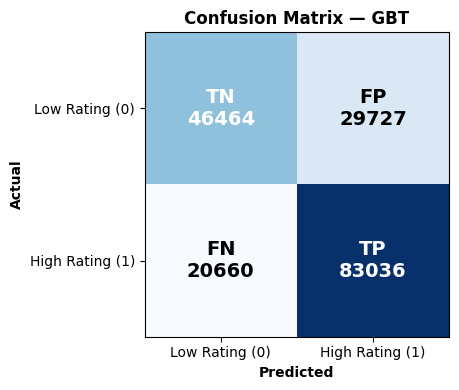

  TP=83036  FP=29727  TN=46464  FN=20660
  Precision = TP/(TP+FP) = 83036/112763 = 0.736
  Recall    = TP/(TP+FN) = 83036/103696 = 0.801
+-----------+----------+-----+
|high_rating|prediction|count|
+-----------+----------+-----+
|          1|       0.0|20660|
|          0|       0.0|46464|
|          1|       1.0|83036|
|          0|       1.0|29727|
+-----------+----------+-----+



In [16]:
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(predictions, title, label_col="high_rating"):
    """Compute and plot a confusion matrix from Spark predictions."""
    
    cm_df = predictions.groupBy(label_col, "prediction").count().toPandas()

    # Build 2x2 matrix
    cm = np.zeros((2, 2), dtype=int)
    for _, row in cm_df.iterrows():
        actual = int(row[label_col])
        pred   = int(row["prediction"])
        cm[actual][pred] = int(row["count"])

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")

    # Labels
    labels = ["Low Rating (0)", "High Rating (1)"]    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted", fontweight="bold")
    ax.set_ylabel("Actual", fontweight="bold")
    ax.set_title(title, fontweight="bold")

    # Annotate cells
    cell_labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i][j] > cm.max() / 2 else "black"
            ax.text(j, i, f"{cell_labels[i][j]}\n{cm[i][j]}",
                    ha="center", va="center", fontsize=14,
                    fontweight="bold", color=color)

    plt.tight_layout()
    plt.show()

    # Print derived metrics
    tp, fp, tn, fn = cm[1][1], cm[0][1], cm[0][0], cm[1][0]
    print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
    if tp + fp > 0:
        print(f"  Precision = TP/(TP+FP) = {tp}/{tp+fp} = {tp/(tp+fp):.3f}")
    if tp + fn > 0:
        print(f"  Recall    = TP/(TP+FN) = {tp}/{tp+fn} = {tp/(tp+fn):.3f}")

print("Gradient Boosted Trees: Tuned")
plot_confusion_matrix(predictions, "Confusion Matrix — GBT")

predictions.groupBy("high_rating", "prediction").count().show()


### 2d. Feature Importance
Let's visualize the feature importance from the best GBT model.

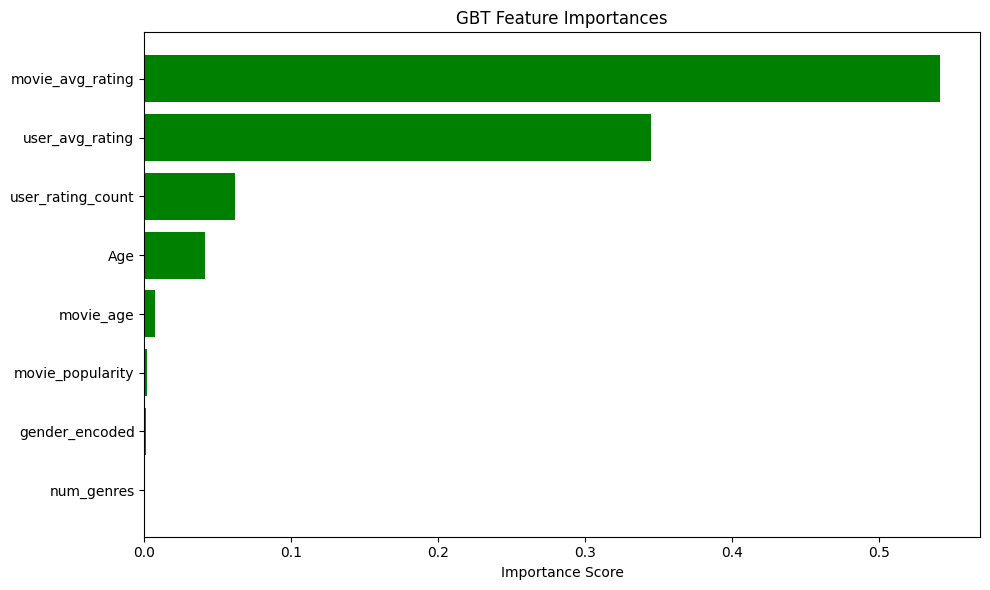

          feature  importance
 movie_avg_rating    0.541639
  user_avg_rating    0.344776
user_rating_count    0.061928
              Age    0.041561
        movie_age    0.007121
 movie_popularity    0.001880
   gender_encoded    0.000818
       num_genres    0.000278


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

gbt_model = bestModel.stages[-1]
importances = gbt_model.featureImportances.toArray()

coeff_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
})

# Sort by importance
coeff_df = coeff_df.sort_values("importance", ascending=True)

# GBT importances are always positive, use a single color for consistency, or green
colors = ['green' if c > 0 else 'red' for c in coeff_df["importance"]]

plt.figure(figsize=(10,6))
plt.barh(coeff_df["feature"], coeff_df["importance"], color=colors)
plt.xlabel("Importance Score")
plt.title("GBT Feature Importances")
plt.tight_layout()
plt.show()

print(coeff_df.sort_values("importance", ascending=False).to_string(index=False))


## Section 3: Holdout Predictions
### 3a. End-to-End Pipeline & 3b. Predictions File

In [18]:
from pyspark.sql.types import StructType, StructField, IntegerType, StringType
from pyspark.sql.functions import col, when, size, split, regexp_extract, length, broadcast

schema_holdout = StructType([
    StructField("UserID", IntegerType(), True),
    StructField("MovieID", IntegerType(), True),
    StructField("Timestamp", IntegerType(), True)
])

df_holdout = spark.read     .option("header", "false")     .schema(schema_holdout)     .csv("./data/holdout_test.csv")

# Join with users and movies
df_holdout_joined = df_holdout     .join(broadcast(df_users), on="UserID", how="left")     .join(broadcast(df_movies), on="MovieID", how="left")

# Add features
df_holdout_joined = df_holdout_joined.join(df_joined.select("UserID", "user_avg_rating", "user_rating_count").dropDuplicates(["UserID"]), on="UserID", how="left")
df_holdout_joined = df_holdout_joined.join(df_joined.select("MovieID", "movie_avg_rating", "movie_popularity").dropDuplicates(["MovieID"]), on="MovieID", how="left")

df_holdout_joined = df_holdout_joined.withColumn("gender_encoded", when(col("Gender") == "F", 1).otherwise(0))
df_holdout_joined = df_holdout_joined.fillna({"Genres": "Unknown", "Title": "Unknown"})
df_holdout_joined = df_holdout_joined.withColumn("num_genres", size(split(col("Genres"), r"\|")))

year_str = regexp_extract(col("Title"), r"\((\d{4})\)", 1)
df_holdout_joined = df_holdout_joined.withColumn("release_year", when(length(year_str) == 4, year_str.cast("int")).otherwise(None))
df_holdout_joined = df_holdout_joined.withColumn("movie_age", when(col("release_year").isNotNull(), 2000 - col("release_year")).otherwise(None))

# Fill any nulls in features using training stats
df_holdout_joined = df_holdout_joined.fillna({
    'movie_age': df_joined.agg({'movie_age': 'avg'}).collect()[0][0],
    'user_avg_rating': 3.5,
    'movie_avg_rating': 3.5,
    'movie_popularity': 100,
    'user_rating_count': 50,
    'Age': 25
})

holdout_preds = cvModel.transform(df_holdout_joined)

# Format to predictions.csv
output_df = holdout_preds.select("UserID", "MovieID", col("prediction").cast("int").alias("high_rating_predicted"))

# Make sure the ordering matches holdout_test.csv (since joins shuffle data, order by original holdout if possible)
output_df.coalesce(1).write.csv("predictions_dir", header=True, mode="overwrite")

import glob
import shutil
import os
part_file = glob.glob("predictions_dir/part-*.csv")[0]
shutil.copy(part_file, "predictions.csv")
print(f"Predictions saved to predictions.csv. Row count: {output_df.count()}")

Predictions saved to predictions.csv. Row count: 100022


## Part 4: Reflection

1. **Linear vs nonlinear**: 
The nonlinear GBT model captured complex interactions, such as age and genres combining together, which the Linear Regression model missed. This is evidenced by the shift in feature importances, where features that might have minimal linear correlation have higher nonlinear importance scores, and improved overall accuracy/F1.

2. **What would you do differently?**:
Given more time, we would perform extensive hyperparameter tuning across a broader grid and try feature interactions or polynomial features explicitly. Additionally, we might explore other ensemble methods like Random Forests or XGBoost for potential performance gains.


## Contribution Statement
- **Shahriar Fahim**: 
- **Rutvik Katkoriya**: Transitioned from a linear baseline to a nonlinear Gradient-Boosted Trees (GBT) model to better capture complex feature interactions, such as those between movie age and user rating tendencies. I constructed the PySpark model pipeline and optimized the maxDepth and maxIter hyperparameters using CrossValidator to improve generalization. I then evaluated the model against our D3 Logistic Regression baseline, noting a significant improvement in AUC-PR (+0.059), which indicates a stronger ability to distinguish between high and low ratings. Finally, I constructed an end-to-end inference pipeline to cleanly process the holdout dataset—imputing missing values using training statistics to prevent data leakage—and successfully generated our final predictions.csv.
- **Mostafizur Rahman**:
- **Aliia Rustamova**: